# ML PROJECT 1
# CLASSIFICATION DATASET :  DIABETES DATASET

In [1]:
import pandas as pd
import numpy as np
import seaborn as sns
from sklearn.preprocessing import LabelEncoder
from sklearn.model_selection import train_test_split
from sklearn.tree import DecisionTreeClassifier
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LogisticRegression
from sklearn.neighbors import KNeighborsClassifier
from sklearn.svm import SVC
from sklearn.naive_bayes import GaussianNB
from sklearn.ensemble import RandomForestClassifier
from imblearn.over_sampling import SMOTE
from sklearn.metrics import accuracy_score
from sklearn.model_selection import GridSearchCV 
from sklearn.model_selection import RandomizedSearchCV
from sklearn.metrics import confusion_matrix, classification_report

In [ ]:
--- DATA LOAD ---

In [2]:
df=pd.read_csv("C:/Users/YUKESH/Downloads/Diabetes_dataset.csv")
df

,Name,gender,age,hypertension,heart_disease,smoking_history,bmi,HbA1c_level,blood_glucose_level,diabetes
0,Dinesh Kumar,Female,80.0,0,1,never,25.19,6.6,140,No
1,Kavin Devi,Female,54.0,0,0,No Info,27.32,6.6,80,No
2,Aarthi Verma,Male,28.0,0,0,never,27.32,5.7,158,No
3,Riya Raj,Female,36.0,0,0,current,23.45,5.0,155,No
4,Rohit Raj,Male,76.0,1,1,current,20.14,4.8,155,No
...,...,...,...,...,...,...,...,...,...,...
9995,Sanjay Das,Female,9.0,0,0,never,25.28,5.8,130,No
9996,Aakash Raj,Male,59.0,0,0,ever,35.00,6.8,140,Yes
9997,Arun Devi,Male,2.0,0,0,never,17.43,4.5,126,No
9998,Harish Kumar,Male,61.0,1,0,ever,31.89,5.7,140,No


In [3]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 10000 entries, 0 to 9999
Data columns (total 10 columns):
 #   Column               Non-Null Count  Dtype  
---  ------               --------------  -----  
 0   Name                 10000 non-null  object 
 1   gender               10000 non-null  object 
 2   age                  10000 non-null  float64
 3   hypertension         10000 non-null  int64  
 4   heart_disease        10000 non-null  int64  
 5   smoking_history      10000 non-null  object 
 6   bmi                  10000 non-null  float64
 7   HbA1c_level          10000 non-null  float64
 8   blood_glucose_level  10000 non-null  int64  
 9   diabetes             10000 non-null  object 
dtypes: float64(3), int64(3), object(4)
memory usage: 781.4+ KB


In [ ]:
--- DROPED UNWANTED DATA COLUMN ---

In [4]:
df=df.drop("Name",axis=1)
df

,gender,age,hypertension,heart_disease,smoking_history,bmi,HbA1c_level,blood_glucose_level,diabetes
0,Female,80.0,0,1,never,25.19,6.6,140,No
1,Female,54.0,0,0,No Info,27.32,6.6,80,No
2,Male,28.0,0,0,never,27.32,5.7,158,No
3,Female,36.0,0,0,current,23.45,5.0,155,No
4,Male,76.0,1,1,current,20.14,4.8,155,No
...,...,...,...,...,...,...,...,...,...
9995,Female,9.0,0,0,never,25.28,5.8,130,No
9996,Male,59.0,0,0,ever,35.00,6.8,140,Yes
9997,Male,2.0,0,0,never,17.43,4.5,126,No
9998,Male,61.0,1,0,ever,31.89,5.7,140,No


In [5]:
df.corr(numeric_only=True)

,age,hypertension,heart_disease,bmi,HbA1c_level,blood_glucose_level
age,1.000000,0.247218,0.231777,0.324376,0.112831,0.109457
hypertension,0.247218,1.000000,0.105533,0.134093,0.073425,0.078809
heart_disease,0.231777,0.105533,1.000000,0.054082,0.078553,0.081182
bmi,0.324376,0.134093,0.054082,1.000000,0.081834,0.085764
HbA1c_level,0.112831,0.073425,0.078553,0.081834,1.000000,0.163477
blood_glucose_level,0.109457,0.078809,0.081182,0.085764,0.163477,1.000000


In [ ]:
--- HYPOTHESIS TESTING ---

In [6]:
import pandas as pd
from scipy.stats import chi2_contingency

table = pd.crosstab(df['gender'], df['diabetes'])


chi2_stat, p_val, dof, expected = chi2_contingency(table)
print( chi2_stat)
print(p_val)

if p_val < 0.05:
    print("yes")  # Reject the null hypothesis(accpeting alternative)
else:
    print("no")  # Fail to reject the null hypothesis

10.514542194512103
0.0011843876982338155
yes


In [7]:
import pandas as pd
from scipy.stats import chi2_contingency

table = pd.crosstab(df['smoking_history'], df['diabetes'])


chi2_stat, p_val, dof, expected = chi2_contingency(table)
print( chi2_stat)
print(p_val)

if p_val < 0.05:
    print("yes")  # Reject the null hypothesis(accpeting alternative)
else:
    print("no")  # Fail to reject the null hypothesis

215.99356365113195
1.0717452568607693e-44
yes


In [ ]:
--- ENCODING ---

In [8]:
hh=LabelEncoder()

df["diabetes"]=hh.fit_transform(df["diabetes"])
df["gender"]=hh.fit_transform(df["gender"])
df["smoking_history"]=hh.fit_transform(df["smoking_history"])
df

,gender,age,hypertension,heart_disease,smoking_history,bmi,HbA1c_level,blood_glucose_level,diabetes
0,0,80.0,0,1,4,25.19,6.6,140,0
1,0,54.0,0,0,0,27.32,6.6,80,0
2,1,28.0,0,0,4,27.32,5.7,158,0
3,0,36.0,0,0,1,23.45,5.0,155,0
4,1,76.0,1,1,1,20.14,4.8,155,0
...,...,...,...,...,...,...,...,...,...
9995,0,9.0,0,0,4,25.28,5.8,130,0
9996,1,59.0,0,0,2,35.00,6.8,140,1
9997,1,2.0,0,0,4,17.43,4.5,126,0
9998,1,61.0,1,0,2,31.89,5.7,140,0


In [ ]:
--- HANDLING NULL VALUES --- 

In [9]:
df.isnull().sum()

gender                 0
age                    0
hypertension           0
heart_disease          0
smoking_history        0
bmi                    0
HbA1c_level            0
blood_glucose_level    0
diabetes               0
dtype: int64

In [ ]:
--- IN THIS DATASET, NO MISSING VALUE ARE PRESENT ---

In [ ]:
--- CHECKING THE OUTLIERS ---

<Axes: xlabel='bmi'>

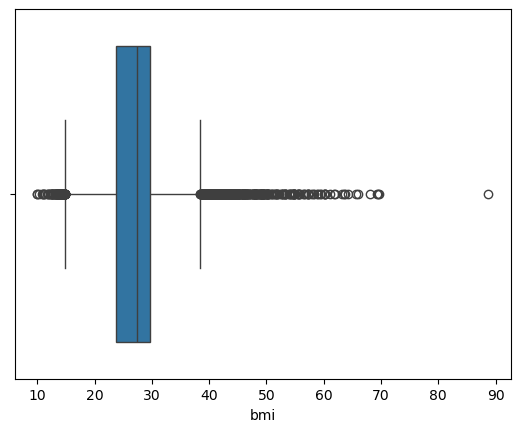

In [10]:
sns.boxplot(x="bmi",data=df)

<Axes: xlabel='HbA1c_level'>

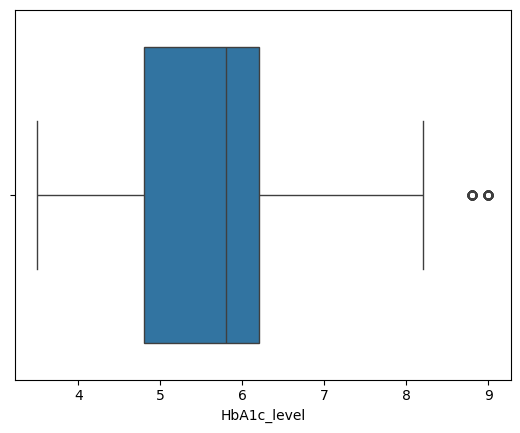

In [11]:
sns.boxplot(x="HbA1c_level",data=df)

<Axes: xlabel='blood_glucose_level'>

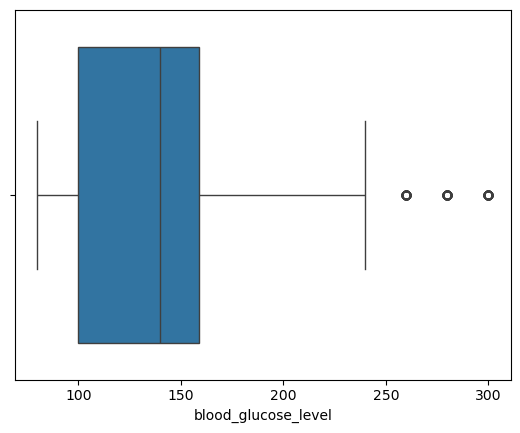

In [12]:
sns.boxplot(x="blood_glucose_level",data=df)

In [ ]:
--- SPLITING Y AND X ---

In [13]:
y=df["diabetes"]
y

0       0
1       0
2       0
3       0
4       0
       ..
9995    0
9996    1
9997    0
9998    0
9999    0
Name: diabetes, Length: 10000, dtype: int64

In [14]:
x=df.drop("diabetes",axis=1)
x

,gender,age,hypertension,heart_disease,smoking_history,bmi,HbA1c_level,blood_glucose_level
0,0,80.0,0,1,4,25.19,6.6,140
1,0,54.0,0,0,0,27.32,6.6,80
2,1,28.0,0,0,4,27.32,5.7,158
3,0,36.0,0,0,1,23.45,5.0,155
4,1,76.0,1,1,1,20.14,4.8,155
...,...,...,...,...,...,...,...,...
9995,0,9.0,0,0,4,25.28,5.8,130
9996,1,59.0,0,0,2,35.00,6.8,140
9997,1,2.0,0,0,4,17.43,4.5,126
9998,1,61.0,1,0,2,31.89,5.7,140


In [ ]:
--- TRAINING PROCESS ---

In [15]:
x_train,x_test,y_train,y_test=train_test_split(x,y,test_size=0.2,random_state=42)

In [ ]:
--- HADALING IMBALANCE DATA ---

In [16]:
y_train.value_counts()

diabetes
0    7307
1     693
Name: count, dtype: int64

In [17]:
smote = SMOTE(sampling_strategy='minority')
x_sm, y_sm = smote.fit_resample(x_train, y_train)
y_sm.value_counts()

diabetes
0    7307
1    7307
Name: count, dtype: int64

In [ ]:
--- SCALING ---

In [18]:
scale=StandardScaler()
x_train_scaled=scale.fit_transform(x_train)
x_test_scaled=scale.transform(x_test)

In [ ]:
--- MODEL 1 ---
--- LOGISTIC REGRESSION ---

In [20]:
model1=LogisticRegression()
model1.fit(x_train,y_train)

C:\Users\YUKESH\anaconda3\Lib\site-packages\sklearn\linear_model\_logistic.py:473: ConvergenceWarning: lbfgs failed to converge after 100 iteration(s) (status=1):
STOP: TOTAL NO. OF ITERATIONS REACHED LIMIT

Increase the number of iterations to improve the convergence (max_iter=100).
You might also want to scale the data as shown in:
    https://scikit-learn.org/stable/modules/preprocessing.html
Please also refer to the documentation for alternative solver options:
    https://scikit-learn.org/stable/modules/linear_model.html#logistic-regression
  n_iter_i = _check_optimize_result(


,penalty,'l2'
,dual,False
,tol,0.0001
,C,1.0
,fit_intercept,True
,intercept_scaling,1
,class_weight,None
,random_state,None
,solver,'lbfgs'
,max_iter,100
,multi_class,'deprecated'


In [21]:
# test_accurarcy
y_pred1=model1.predict(x_test)
accuracy1=accuracy_score(y_test,y_pred1)
accuracy1

0.9585

In [22]:
# training _accuracy 
y_train_pred1=model1.predict(x_train)
final_training1=accuracy_score(y_train,y_train_pred1)
final_training1

0.95925

In [23]:
# classification_report
cr1 = classification_report(y_test, y_pred1, target_names=["No diabetes no as 0", "diabetes yes as 1"])
print("\nLogistic Regression:")
print("\nClassification Report:")
print(cr1)


Logistic Regression:

Classification Report:
                     precision    recall  f1-score   support

No diabetes no as 0       0.97      0.99      0.98      1834
  diabetes yes as 1       0.81      0.66      0.72       166

           accuracy                           0.96      2000
          macro avg       0.89      0.82      0.85      2000
       weighted avg       0.96      0.96      0.96      2000



In [ ]:
--- MODEL 2 ---
--- KNN [K NEAREST NEIGHBORS CLASSIFIER] ---

In [24]:
model2=KNeighborsClassifier()
model2.fit(x_train,y_train)

,n_neighbors,5
,weights,'uniform'
,algorithm,'auto'
,leaf_size,30
,p,2
,metric,'minkowski'
,metric_params,None
,n_jobs,None


In [25]:
# testing_accuracy
y_pred2=model2.predict(x_test)
accuracy2=accuracy_score(y_test,y_pred2)
accuracy2

0.9465

In [26]:
# training _accuracy 
y_train_pred2=model2.predict(x_train)
final_training2=accuracy_score(y_train_pred2,y_train)
final_training2

0.9555

In [27]:
# hyper parameter
model_2=KNeighborsClassifier()

parameter = {'n_neighbors': [3,5,7], 'metric': ['euclidean', 'manhattan'] }

grid = GridSearchCV( estimator=model_2, param_grid=parameter, cv=5, scoring='accuracy' )

grid.fit(x_train,y_train)

print("Best parameters:", grid.best_params_)

print("Best CV score:", grid.best_score_)

Best parameters: {'metric': 'manhattan', 'n_neighbors': 5}
Best CV score: 0.9478750000000001


In [28]:
# Applying best parameter
model_2=KNeighborsClassifier(metric='euclidean',n_neighbors=5)

In [29]:
# testing_accuracy (after applying best parameter)
model_2.fit(x_train,y_train)
y_pred_2=model_2.predict(x_test)
accuracy_2=accuracy_score(y_test,y_pred_2)
accuracy_2

0.9465

In [30]:
# training _accuracy 
y_train_pred_2=model_2.predict(x_train)
final_training_2=accuracy_score(y_train,y_train_pred_2)
final_training_2

0.9555

In [31]:
# clssification_report
cr2 = classification_report(y_test, y_pred_2, target_names=["No diabetes no as 0", "diabetes yes as 1"])
print("\nK Nearest Neighbors:")
print("\nClassification Report:")
print(cr2)


K Nearest Neighbors:

Classification Report:
                     precision    recall  f1-score   support

No diabetes no as 0       0.95      0.99      0.97      1834
  diabetes yes as 1       0.83      0.45      0.58       166

           accuracy                           0.95      2000
          macro avg       0.89      0.72      0.78      2000
       weighted avg       0.94      0.95      0.94      2000



In [ ]:
--- MODEL 3 ---
--- SVM [SUPPORT VECTOR MACHINE CLASSIFIER] ---

In [32]:
model3=SVC()
model3.fit(x_train,y_train)

,C,1.0
,kernel,'rbf'
,degree,3
,gamma,'scale'
,coef0,0.0
,shrinking,True
,probability,False
,tol,0.001
,cache_size,200
,class_weight,None
,verbose,False


In [33]:
# testing_accuracy
y_pred3=model3.predict(x_test)
accuracy3=accuracy_score(y_test,y_pred3)
accuracy3

0.9425

In [34]:
# training _accuracy 
y_train_pred3=model3.predict(x_train)
final_training3=accuracy_score(y_train,y_train_pred3)
final_training3

0.941875

In [35]:
# classification_report
cr3 = classification_report(y_test, y_pred3, target_names=["No diabetes no as 0", "diabetes yes as 1"])
print("\nSupport vector machine:")
print("\nClassification Report:")
print(cr3)


Support vector machine:

Classification Report:
                     precision    recall  f1-score   support

No diabetes no as 0       0.94      1.00      0.97      1834
  diabetes yes as 1       1.00      0.31      0.47       166

           accuracy                           0.94      2000
          macro avg       0.97      0.65      0.72      2000
       weighted avg       0.95      0.94      0.93      2000



In [36]:
# Define the model
model_3 = SVC()

# Define parameter grid
parameter = {'C': [0.1, 1, 7,0.4], 'kernel': ['linear', 'rbf'] }

# Grid Search
ran = RandomizedSearchCV( estimator=model_3, param_distributions=parameter, cv=5, scoring='accuracy' )

# Fit using your own training data
ran.fit(x_train, y_train)

# Best parameters
print("Best parameters:", ran.best_params_)

# Best CV score
print("Best CV score:", ran.best_score_)

C:\Users\YUKESH\anaconda3\Lib\site-packages\sklearn\model_selection\_search.py:317: UserWarning: The total space of parameters 8 is smaller than n_iter=10. Running 8 iterations. For exhaustive searches, use GridSearchCV.
  warnings.warn(


Best parameters: {'kernel': 'linear', 'C': 0.1}
Best CV score: 0.96225


In [37]:
model_3=SVC(kernel='linear', C= 0.1)
model_3.fit(x_train,y_train)
y_pred_3=model_3.predict(x_test)
accuracy_3=accuracy_score(y_test,y_pred_3)
accuracy_3

0.962

In [38]:
# training _accuracy 
y_train_pred_3=model_3.predict(x_train)
final_training_3=accuracy_score(y_train,y_train_pred_3)
final_training_3

0.962625

In [39]:
# classification_report
cr3 = classification_report(y_test, y_pred_3, target_names=["No diabetes no as 0", "diabetes yes as 1"])
print("\nSupport vector machine:")
print("\nClassification Report:")
print(cr3)


Support vector machine:

Classification Report:
                     precision    recall  f1-score   support

No diabetes no as 0       0.97      0.99      0.98      1834
  diabetes yes as 1       0.89      0.61      0.73       166

           accuracy                           0.96      2000
          macro avg       0.93      0.80      0.85      2000
       weighted avg       0.96      0.96      0.96      2000



In [40]:
df1=df.copy()
df1

,gender,age,hypertension,heart_disease,smoking_history,bmi,HbA1c_level,blood_glucose_level,diabetes
0,0,80.0,0,1,4,25.19,6.6,140,0
1,0,54.0,0,0,0,27.32,6.6,80,0
2,1,28.0,0,0,4,27.32,5.7,158,0
3,0,36.0,0,0,1,23.45,5.0,155,0
4,1,76.0,1,1,1,20.14,4.8,155,0
...,...,...,...,...,...,...,...,...,...
9995,0,9.0,0,0,4,25.28,5.8,130,0
9996,1,59.0,0,0,2,35.00,6.8,140,1
9997,1,2.0,0,0,4,17.43,4.5,126,0
9998,1,61.0,1,0,2,31.89,5.7,140,0


In [41]:
y=df1["diabetes"]
y

0       0
1       0
2       0
3       0
4       0
       ..
9995    0
9996    1
9997    0
9998    0
9999    0
Name: diabetes, Length: 10000, dtype: int64

In [42]:
x=df1.drop("diabetes",axis=1)
x

,gender,age,hypertension,heart_disease,smoking_history,bmi,HbA1c_level,blood_glucose_level
0,0,80.0,0,1,4,25.19,6.6,140
1,0,54.0,0,0,0,27.32,6.6,80
2,1,28.0,0,0,4,27.32,5.7,158
3,0,36.0,0,0,1,23.45,5.0,155
4,1,76.0,1,1,1,20.14,4.8,155
...,...,...,...,...,...,...,...,...
9995,0,9.0,0,0,4,25.28,5.8,130
9996,1,59.0,0,0,2,35.00,6.8,140
9997,1,2.0,0,0,4,17.43,4.5,126
9998,1,61.0,1,0,2,31.89,5.7,140


In [43]:
x_train1,x_test1,y_train1,y_test1=train_test_split(x,y,test_size=0.2,random_state=42)

In [ ]:
--- MODEL 4 ---
--- DECISION TREE CLASSIFIER ---

In [44]:
model4=DecisionTreeClassifier()
model4.fit(x_train1, y_train1)

,criterion,'gini'
,splitter,'best'
,max_depth,None
,min_samples_split,2
,min_samples_leaf,1
,min_weight_fraction_leaf,0.0
,max_features,None
,random_state,None
,max_leaf_nodes,None
,min_impurity_decrease,0.0
,class_weight,None


In [45]:
# test_accurarcy
y_pred4=model4.predict(x_test1)
accuracy4=accuracy_score(y_test1,y_pred4)
accuracy4

0.952

In [46]:
# training _accuracy 
y_train_pred4=model4.predict(x_train1)
final_training4=accuracy_score(y_train1,y_train_pred4)
final_training4

1.0

In [47]:
# Hyperparameter
model_4=DecisionTreeClassifier()
param_grid = {
    'max_depth': [3, 5, 10],
    'min_samples_split': [2,5,6,7,3,10],
    'min_samples_leaf': [1, 2,3,4]
}

# GridSearchCV
grid_search = GridSearchCV(estimator=model_4, param_grid=param_grid, cv=5, scoring='accuracy', n_jobs=-1)

# Train
grid_search.fit(x_train1, y_train1)

# Best parameters
print("Best Parameters:", grid_search.best_params_)

# Best model
best_model = grid_search.best_estimator_

# Test accuracy
y_pred = best_model.predict(x_test)
print("Accuracy:", accuracy_score(y_test,y_pred))

Best Parameters: {'max_depth': 3, 'min_samples_leaf': 1, 'min_samples_split': 2}
Accuracy: 0.972


In [48]:
# The best parameter for decision tree 
model_4=DecisionTreeClassifier(max_depth= 3, min_samples_leaf= 1, min_samples_split= 2)

In [49]:
# test_accurarcy
model_4.fit(x_train1,y_train1)
y_pred_4=model_4.predict(x_test1)
accuracy_4=accuracy_score(y_test1,y_pred_4)
accuracy_4

0.972

In [50]:
# training _accuracy 
y_train_pred_4=model_4.predict(x_train1)
final_training_4=accuracy_score(y_train1,y_train_pred_4)
final_training_4

0.972375

In [51]:
# classification_report
cr4 = classification_report(y_test1, y_pred_4, target_names=["No diabetes no as 0", "diabetes yes as 1"])
print("\nDecision tree:")
print("\nClassification Report:")
print(cr4)


Decision tree:

Classification Report:
                     precision    recall  f1-score   support

No diabetes no as 0       0.97      1.00      0.98      1834
  diabetes yes as 1       1.00      0.66      0.80       166

           accuracy                           0.97      2000
          macro avg       0.99      0.83      0.89      2000
       weighted avg       0.97      0.97      0.97      2000

